# 01 — Dataset Exploration

This notebook loads all four PROMs datasets, explains the scoring methodology, and compares hip vs knee outcomes to justify focusing on the `df_knee_provider` dataset. It also includes some initial EDA and necessary data cleaning to get to the first dataset we want to focus on.

In [1]:
import pandas as pd
import numpy as np

df_hip_ccg = pd.read_parquet("../data/interim/hip-ccg.parquet")
df_knee_ccg = pd.read_parquet("../data/interim/knee-ccg.parquet")
df_hip_provider = pd.read_parquet("../data/interim/hip-provider.parquet")
df_knee_provider = pd.read_parquet("../data/interim/knee-provider.parquet")

# **Important things to keep in mind based on the description provided in references, proms_guide_V12.pdf"**

## Overview

For each patient, the PROMs dataset includes the following:
- Patient-identifiable information, which is used for linkage purposes and not made
available for wider analysis.
- A condition-specific measure of self-reported health status.
- Generic measures of self-reported health status.
- Additional questions about the patient’s own health, including whether they have preexisting conditions such as arthritis or diabetes.

Before a patient undergoes one of the four PROMs procedures, the provider should offer the
patient a PROMs questionnaire for completion. The guidance states that this should happen
in the interval between the patient being passed fit for surgery and the treatment taking
place. However, there is local discretion as to when precisely it is administered before the
procedure. Completion of the pre-operative PROMs questionnaire is voluntary for the patient
and their consent to participate must be granted for the data to be processed and used. 

## Scoring methodologies

The PROMs programme utilises a number of tested and well-established methodologies to
enable patients to rate their health status.
All patients, irrespective of their condition, are asked to complete a common set of questions
about their health status. This includes sections about the patient’s circumstances, preexisting conditions and the EQ-5DTM health questionnaire consisting of a five-dimensional
descriptive system and a visual analogue scale (EQ-VAS) developed by the EuroQol Group.
Post-operative questionnaires also contain additional questions about the surgery, such as
how the patient perceives the results of the operation and whether there were any postoperative complications, such as bleeding or wound problems.
Patients undergoing varicose vein treatment or hip and knee replacement surgery are also
asked to complete a condition-specific section.

### *EQ-5DTM*

EQ-5DTM is a standardised measure of health status developed by the EuroQol Group in
order to provide a simple, generic measure of health for clinical and economic appraisal.
Applicable to a wide range of health conditions and treatments, it provides a simple
descriptive profile and a single index value for health status that can be used in the clinical
and economic evaluation of healthcare as well as in population health surveys.
EQ-5DTM consists of two distinct sections, the EQ-5DTM descriptive system and the EQ-5DTM
visual analogue scale (EQ-VAS).
The EQ-5DTM descriptive system comprises the following five dimensions:
- Mobility
- Self-care e.g. washing and dressing
- Usual activities e.g. work, study, housework, family or leisure activities
- Pain / discomfort
- Anxiety / depression.

Each dimension has three levels: no problems, some problems, severe problems. The
respondent is asked to indicate his / her health state by ticking (or placing a cross) in the box
against the most appropriate statement in each of the five dimensions. This decision results
in a one-digit number expressing the level selected for that dimension. The digits for five
dimensions can be combined in a five-digit number string describing the respondent’s health
state, also referred to as the EQ-5DTM
’health profile’.
EQ-5DTM health states are converted into a single summary index by applying a formula that
essentially attaches values (also called ‘social preference weights’) to each of the levels in
each dimension. The index can be calculated by deducting the appropriate weights from
one, the value for full health (i.e. state 11111).
EQ-VAS consists of a simple scale, from 0 to 100, presented in a simple linear format.
Respondents are asked to rate their health state by marking the scale at the relevant point,
with zero being the worst and one hundred being the best state. See Annex 2 for more
information on the EQ-5DTM scoring system.

### *OHS and OKS*

The Oxford hip and knee scores are joint-specific outcome measure tools designed to
assess symptoms and function in patients undergoing joint replacement surgery.
The scores comprise of twelve multiple choice questions relating to the patient’s experience
of pain, ease of joint movement and ease of undertaking normal domestic activities such as
walking or climbing stairs.
Each of the 12 questions on the Oxford Hip Score and Oxford Knee Score are scored in the
same way with the score decreasing as the reported symptoms increase, i.e. become worse.
All questions are laid out similarly with response categories denoting least (or no) symptoms
scoring four and those representing greatest severity scoring zero.
The individual scores are then added together to provide a single score with 0 indicating the
worst possible and 48 indicating the highest possible score.

## Potential issues with the data

HES episodes that do not link to PROMs (unlinked episodes):
- Completion of PROMs is voluntary: patients are not obliged to take part in the PROMs
programme at either Q1 or Q2 stage.
- Lag or ‘lead in’ time before the operation: in many cases providers are administering their
Q1 questionnaire at a pre-assessment clinic up to several weeks before surgery is
scheduled. This means that a high proportion of patients who had *episodes* early in the
year would not have been invited to take part. Some patients with episodes in April would
not have completed Q1 questionnaires and many patients who had completed Q1s in
April would not have had their operation until several weeks or even months later. This
will have the effect of underestimating actual linkage performance.
- Provider mapping issues: there are instances where the Q1 may be administered to a
patient at one hospital and the operation performed at another. This may be due to
provider subcontracting arrangements, patient choice or shared pathways. The matching
algorithm can take many of these provider-to-provider relationships into account where
they are known but there will always be relationships between providers that are not
recognised.

### *Missing Values*

In instances where a patient may have either declined to answer or accidentally missed a
question, a default value is inserted to indicate a null value. For the majority of the multiple
choice questions, NULL values are replaced with a 9. For the EQ-5DTM VAS, 999 is used
because in that case 9 is a valid response.

The second exception is for the Oxford orthopaedic scores, for which the PROMs
programme adopts the permitted option to impute of missing values as the average of
present responses provided that no more than two responses are missing. Where more than
two responses are missing, the overall score is not calculated.


### **General data inspection of all files**

In [2]:
# List of dataframe variable names
df_names = ["df_hip_ccg", "df_knee_ccg", "df_hip_provider", "df_knee_provider"]

for df_name in df_names:
    print(f"\n--- {df_name} ---")
    df = globals().get(df_name)
    if df is not None:
        print("Columns:", df.columns.tolist())
        print("Missing values per column:\n", df.isnull().sum())
        print("Describe:\n", df.describe(include='all'))
    else:
        print(f"{df_name} not loaded.")


--- df_hip_ccg ---
Columns: ['provider_code', 'procedure', 'revision_flag', 'year', 'age_band', 'gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_living_arrangements', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility', 't0_self_care', 't0_activity', 't0_discomfort', 't0_anxiety', 't0_eq5d_index_profile', 't0_eq5d_index', 't1_assisted', 't1_assisted_by', 't1_living_arrangements', 't1_disability', 't1_mobility', 't1_self_care', 't1_activity', 't1_discomfort', 't1_anxiety', 't1_satisfaction', 't1_sucess', 't1_allergy', 't1_bleeding', 't1_wound', 't1_urine', 't1_further_surgery', 't1_readmitted', 't1_eq5d_index_profile', 't1_eq5d_index', 'ohs_eq5d_index_t1_predicted', 't0_eq_vas', 't1_eq_vas', 'ohs_eq_vas_t1_predicted', 'ohs_t0_pain', 'ohs_t0_sudden_pain', 'ohs_t0_night_pain', 'ohs_t0_washing', 'ohs

In [3]:
import numpy as np
import pandas as pd

def analyze_missing_scores(df, df_name):
    """Analyze missing values for PROMs scores in a dataset with formatted tables."""
    
    print(f"\n{'='*80}")
    print(f"ANALYSIS FOR: {df_name}")
    print(f"{'='*80}")
    
    if df is None:
        print(f"{df_name} not loaded.")
        return
    
    print(f"Total records: {len(df):,}\n")
    
    # Define columns to check
    columns_of_interest = [
        "t0_eq_vas", "t1_eq_vas",
        "t0_eq5d_index", "t1_eq5d_index",
        "oks_t0_score", "oks_t1_score",
        "oks_t0_score", "oks_t1_score"
    ]
    
    existing_cols = [col for col in columns_of_interest if col in df.columns]
    
    if not existing_cols:
        print("None of the standard PROMs columns found in this dataset.")
        return
    
    # Create missing values table
    print("MISSING VALUES SUMMARY:")
    missing_data = []
    for col in existing_cols:
        missing = df[col].isnull().sum()
        present = len(df) - missing
        missing_pct = (missing / len(df)) * 100
        present_pct = 100 - missing_pct
        missing_data.append({
            'Column': col,
            'Present': f"{present:,}",
            'Missing': f"{missing:,}",
            'Missing %': f"{missing_pct:.2f}%",
            'Present %': f"{present_pct:.2f}%"
        })
    
    missing_df = pd.DataFrame(missing_data)
    print(missing_df.to_string(index=False))
    print()
    
    # Helper function for paired analysis
    def create_paired_table(t0_col, t1_col, score_name, replace_999=False):
        if t0_col not in df.columns or t1_col not in df.columns:
            return
        
        print(f"\n{score_name} COMPLETENESS:")
        
        df_temp = df.replace(999, np.nan) if replace_999 else df
        
        total = len(df)
        t0_answered = df_temp[t0_col].notna().sum()
        t1_answered = df_temp[t1_col].notna().sum()
        both_answered = df_temp[[t0_col, t1_col]].notna().all(axis=1).sum()
        t0_only = df_temp[t0_col].notna().sum() - both_answered
        t1_only = df_temp[t1_col].notna().sum() - both_answered
        neither = total - t0_answered - t1_only
        
        completeness_data = [
            {
                'Category': 'Both t0 AND t1',
                'Count': f"{both_answered:,}",
                'Percentage': f"{(both_answered/total)*100:.2f}%"
            },
            {
                'Category': 't0 only',
                'Count': f"{t0_only:,}",
                'Percentage': f"{(t0_only/total)*100:.2f}%"
            },
            {
                'Category': 't1 only',
                'Count': f"{t1_only:,}",
                'Percentage': f"{(t1_only/total)*100:.2f}%"
            },
            {
                'Category': 'Neither t0 nor t1',
                'Count': f"{neither:,}",
                'Percentage': f"{(neither/total)*100:.2f}%"
            },
            {
                'Category': '─' * 20,
                'Count': '─' * 10,
                'Percentage': '─' * 10
            },
            {
                'Category': 'Total with t0',
                'Count': f"{t0_answered:,}",
                'Percentage': f"{(t0_answered/total)*100:.2f}%"
            },
            {
                'Category': 'Total with t1',
                'Count': f"{t1_answered:,}",
                'Percentage': f"{(t1_answered/total)*100:.2f}%"
            }
        ]
        
        completeness_df = pd.DataFrame(completeness_data)
        print(completeness_df.to_string(index=False))
    
    # Analyze each score type
    create_paired_table("oks_t0_score", "oks_t1_score", "OXFORD HIP SCORE (OHS)")
    create_paired_table("oks_t0_score", "oks_t1_score", "OXFORD KNEE SCORE (OKS)")
    create_paired_table("t0_eq_vas", "t1_eq_vas", "EQ5D VAS (999 treated as missing)", replace_999=True)
    create_paired_table("t0_eq5d_index", "t1_eq5d_index", "EQ5D INDEX")


# List of all datasets to analyze
datasets_to_check = [
    "df_hip_provider",
    "df_hip_ccg",
    "df_knee_provider",
    "df_knee_ccg"
]

# Run analysis for each dataset
for dataset_name in datasets_to_check:
    df = globals().get(dataset_name)
    analyze_missing_scores(df, dataset_name)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


ANALYSIS FOR: df_hip_provider
Total records: 124,844

MISSING VALUES SUMMARY:
       Column Present Missing Missing % Present %
    t0_eq_vas 124,844       0     0.00%   100.00%
    t1_eq_vas 124,844       0     0.00%   100.00%
t0_eq5d_index 117,824   7,020     5.62%    94.38%
t1_eq5d_index 119,467   5,377     4.31%    95.69%


EQ5D VAS (999 treated as missing) COMPLETENESS:
            Category      Count Percentage
      Both t0 AND t1    108,551     86.95%
             t0 only      5,024      4.02%
             t1 only     10,213      8.18%
   Neither t0 nor t1      1,056      0.85%
──────────────────── ────────── ──────────
       Total with t0    113,575     90.97%
       Total with t1    118,764     95.13%

EQ5D INDEX COMPLETENESS:
            Category      Count Percentage
      Both t0 AND t1    112,971     90.49%
             t0 only      4,853      3.89%
             t1 only      6,496      5.20%
   Neither t0 nor t1        524      0.42%
──────────────────── ────────── ────

In [4]:
import pandas as pd

def analyze_eq5d_profiles(df, df_name):
    """Analyze EQ5D profiles containing '9' and their relationship to NaN indices."""
    
    print(f"\n{'='*80}")
    print(f"EQ5D PROFILE ANALYSIS FOR: {df_name}")
    print(f"{'='*80}")
    
    if df is None:
        print(f"{df_name} not loaded.")
        return
    
    # Check if required columns exist
    profile_cols = [col for col in df.columns if 'eq5d_index_profile' in col]
    index_cols = [col for col in df.columns if col.endswith('eq5d_index') and 'profile' not in col]
    
    if not profile_cols or not index_cols:
        print(f"No EQ5D profile/index columns found in {df_name}")
        return
    
    # Analyze each t0/t1 pair
    for time_point in ['t0', 't1']:
        profile_col = f'{time_point}_eq5d_index_profile'
        index_col = f'{time_point}_eq5d_index'
        
        if profile_col not in df.columns or index_col not in df.columns:
            continue
        
        print(f"\n{'─'*80}")
        print(f"TIME POINT: {time_point.upper()}")
        print(f"{'─'*80}")
        
        # Create working dataframe
        df_check = df[[profile_col, index_col]].copy()
        df_check['profile_str'] = df_check[profile_col].astype(str)
        df_check['contains_9'] = df_check['profile_str'].str.contains('9', na=False)
        
        # Overall summary
        total_rows = len(df_check)
        with_9 = df_check['contains_9'].sum()
        without_9 = (~df_check['contains_9']).sum()
        
        print(f"\nOVERALL SUMMARY:")
        print(f"Total rows: {total_rows:,}")
        print(f"Profiles containing '9': {with_9:,} ({(with_9/total_rows)*100:.2f}%)")
        print(f"Profiles NOT containing '9': {without_9:,} ({(without_9/total_rows)*100:.2f}%)")
        
        # Profiles WITH '9'
        profiles_with_9 = df_check[df_check['contains_9']]
        with_9_nan = profiles_with_9[index_col].isna().sum()
        with_9_not_nan = profiles_with_9[index_col].notna().sum()
        
        # Profiles WITHOUT '9'
        profiles_without_9 = df_check[~df_check['contains_9']]
        without_9_nan = profiles_without_9[index_col].isna().sum()
        without_9_not_nan = profiles_without_9[index_col].notna().sum()
        
        # Create summary table
        summary_data = [
            {
                'Profile Type': "Contains '9'",
                'Total': f"{len(profiles_with_9):,}",
                'Index is NaN': f"{with_9_nan:,}",
                'Index is NOT NaN': f"{with_9_not_nan:,}",
                'NaN %': f"{(with_9_nan/len(profiles_with_9)*100) if len(profiles_with_9) > 0 else 0:.2f}%"
            },
            {
                'Profile Type': "Does NOT contain '9'",
                'Total': f"{len(profiles_without_9):,}",
                'Index is NaN': f"{without_9_nan:,}",
                'Index is NOT NaN': f"{without_9_not_nan:,}",
                'NaN %': f"{(without_9_nan/len(profiles_without_9)*100) if len(profiles_without_9) > 0 else 0:.2f}%"
            }
        ]
        
        summary_df = pd.DataFrame(summary_data)
        print("\nDETAILED BREAKDOWN:")
        print(summary_df.to_string(index=False))
        
        # Check for unusual cases
        print("\nVALIDATION CHECKS:")
        
        # Case 1: Profiles with '9' that have NON-NaN index (should be 0)
        non_nan_with_9 = df_check[df_check['contains_9'] & df_check[index_col].notna()]
        if len(non_nan_with_9) > 0:
            print(f"⚠️  UNUSUAL: {len(non_nan_with_9)} profiles with '9' have NON-NaN index")
            print("\nExamples:")
            print(non_nan_with_9[[profile_col, index_col]].head(10).to_string(index=True))
        else:
            print(f"✓ CONFIRMED: ALL {with_9:,} profiles with '9' result in NaN index")
        
        # Case 2: Profiles without '9' that have NaN (might be other data issues)
        nan_without_9 = df_check[(~df_check['contains_9']) & df_check[index_col].isna()]
        if len(nan_without_9) > 0:
            print(f"\n⚠️  NOTE: {len(nan_without_9):,} profiles WITHOUT '9' still have NaN index")
            print("(This could be due to other data quality issues)")
            print("\nExamples:")
            print(nan_without_9[[profile_col, index_col]].head(10).to_string(index=True))
        else:
            print(f"✓ All profiles without '9' have valid index values")
        
        # Show some examples of profiles with '9'
        if len(profiles_with_9) > 0:
            print(f"\nEXAMPLES OF PROFILES WITH '9':")
            examples = profiles_with_9[[profile_col, index_col]].head(10)
            print(examples.to_string(index=True))


# List of all datasets to analyze
datasets_to_check = [
    "df_hip_provider",
    "df_hip_ccg",
    "df_knee_provider",
    "df_knee_ccg"
]

# Run analysis for each dataset
for dataset_name in datasets_to_check:
    df = globals().get(dataset_name)
    analyze_eq5d_profiles(df, dataset_name)

print("\n" + "="*80)
print("EQ5D PROFILE ANALYSIS COMPLETE")
print("="*80)


EQ5D PROFILE ANALYSIS FOR: df_hip_provider

────────────────────────────────────────────────────────────────────────────────
TIME POINT: T0
────────────────────────────────────────────────────────────────────────────────

OVERALL SUMMARY:
Total rows: 124,844
Profiles containing '9': 7,020 (5.62%)
Profiles NOT containing '9': 117,824 (94.38%)

DETAILED BREAKDOWN:
        Profile Type   Total Index is NaN Index is NOT NaN   NaN %
        Contains '9'   7,020        7,020                0 100.00%
Does NOT contain '9' 117,824            0          117,824   0.00%

VALIDATION CHECKS:
✓ CONFIRMED: ALL 7,020 profiles with '9' result in NaN index
✓ All profiles without '9' have valid index values

EXAMPLES OF PROFILES WITH '9':
     t0_eq5d_index_profile  t0_eq5d_index
38                   92233            NaN
39                   99999            NaN
54                   29122            NaN
82                   99999            NaN
100                  99999            NaN
101              

In [5]:
import pandas as pd
import numpy as np

def simple_t0_t1_analysis(df, df_name):
    """Simple analysis: who filled t0 but not t1, and vice versa."""
    
    if df is None:
        print(f"{df_name} not loaded.\n")
        return None
    
    total = len(df)
    
    # Define t0/t1 pairs to check
    variable_pairs = [
        ('oks_t0_score', 'oks_t1_score', 'Oxford Hip Score'),
        ('oks_t0_score', 'oks_t1_score', 'Oxford Knee Score'),
        ('t0_eq_vas', 't1_eq_vas', 'EQ5D VAS'),
        ('t0_eq5d_index', 't1_eq5d_index', 'EQ5D Index')
    ]
    
    results = []
    
    for t0_col, t1_col, var_name in variable_pairs:
        # Skip if columns don't exist
        if t0_col not in df.columns or t1_col not in df.columns:
            continue
        
        # For VAS, replace 999 with NaN
        if 'vas' in t0_col.lower():
            df_temp = df[[t0_col, t1_col]].replace(999, np.nan)
        else:
            df_temp = df[[t0_col, t1_col]]
        
        # Calculate all four combinations
        both_filled = (df_temp[t0_col].notna() & df_temp[t1_col].notna()).sum()
        t0_only = (df_temp[t0_col].notna() & df_temp[t1_col].isna()).sum()
        t1_only = (df_temp[t0_col].isna() & df_temp[t1_col].notna()).sum()
        neither = (df_temp[t0_col].isna() & df_temp[t1_col].isna()).sum()
        
        results.append({
            'Variable': var_name,
            'Both_t0_t1_count': both_filled,
            'Both_t0_t1_pct': round(both_filled/total*100, 1),
            't0_only_count': t0_only,
            't0_only_pct': round(t0_only/total*100, 1),
            't1_only_count': t1_only,
            't1_only_pct': round(t1_only/total*100, 1),
            'Neither_count': neither,
            'Neither_pct': round(neither/total*100, 1)
        })
    
    if results:
        results_df = pd.DataFrame(results)
        return results_df, total
    else:
        return None, total


# Set display options for better dataframe viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Run for all datasets
datasets = ["df_hip_provider", "df_hip_ccg", "df_knee_provider", "df_knee_ccg"]

all_results = {}

for dataset_name in datasets:
    print(f"\n{'='*80}")
    print(f"{dataset_name}")
    print(f"{'='*80}")
    
    df = globals().get(dataset_name)
    result_df, total = simple_t0_t1_analysis(df, dataset_name)
    
    if result_df is not None:
        print(f"Total patients: {total:,}\n")
        display(result_df)  # Use display() for Jupyter notebooks
        # OR use print(result_df) if not in Jupyter
        all_results[dataset_name] = result_df
    else:
        print("No t0/t1 variable pairs found in this dataset.")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")


df_hip_provider
Total patients: 124,844



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,EQ5D VAS,108551,86.9,5024,4.0,10213,8.2,1056,0.8
1,EQ5D Index,112971,90.5,4853,3.9,6496,5.2,524,0.4



df_hip_ccg
Total patients: 122,294



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,EQ5D VAS,106361,87.0,4899,4.0,9996,8.2,1038,0.8
1,EQ5D Index,110668,90.5,4744,3.9,6369,5.2,513,0.4



df_knee_provider
Total patients: 139,236



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,Oxford Hip Score,135051,97.0,2516,1.8,1606,1.2,63,0.0
1,Oxford Knee Score,135051,97.0,2516,1.8,1606,1.2,63,0.0
2,EQ5D VAS,120904,86.8,5371,3.9,11786,8.5,1175,0.8
3,EQ5D Index,126038,90.5,5698,4.1,6924,5.0,576,0.4



df_knee_ccg
Total patients: 136,390



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,Oxford Hip Score,132269,97.0,2478,1.8,1583,1.2,60,0.0
1,Oxford Knee Score,132269,97.0,2478,1.8,1583,1.2,60,0.0
2,EQ5D VAS,118411,86.8,5248,3.8,11584,8.5,1147,0.8
3,EQ5D Index,123467,90.5,5563,4.1,6794,5.0,566,0.4



ANALYSIS COMPLETE


In [6]:
# Calculate the average improvement (delta) in oks_t1_score - oks_t0_score for df_hip_provider and oks_t1_score - oks_t0_score for df_knee_provider where both scores are filled.

df_hip = globals().get("df_hip_provider")
df_knee = globals().get("df_knee_provider")
if df_hip is not None:
    # Filter for patients with both scores filled
    df_hip_filtered = df_hip.dropna(subset=['ohs_t0_score', 'ohs_t1_score']).copy()
    # Calculate delta
    df_hip_filtered['ohs_delta'] = df_hip_filtered['ohs_t1_score'] - df_hip_filtered['ohs_t0_score']
    # Calculate average improvement
    avg_improvement_hip = df_hip_filtered['ohs_delta'].mean()
    print(f"Average improvement in OHS Score (T1 - T0) for Hip Patients: {avg_improvement_hip:.2f}")

if df_knee is not None:
    # Filter for patients with both scores filled
    df_knee_filtered = df_knee.dropna(subset=['oks_t0_score', 'oks_t1_score']).copy()
    # Calculate delta
    df_knee_filtered['oks_delta'] = df_knee_filtered['oks_t1_score'] - df_knee_filtered['oks_t0_score']
    # Calculate average improvement
    avg_improvement_knee = df_knee_filtered['oks_delta'].mean()
    print(f"Average improvement in OKS Score (T1 - T0) for Knee Patients: {avg_improvement_knee:.2f}")

Average improvement in OHS Score (T1 - T0) for Hip Patients: 21.94
Average improvement in OKS Score (T1 - T0) for Knee Patients: 16.89


In [8]:
# Beautiful Altair Visualizations: Knee vs Hip Provider Comparison
# Focus on score improvements and the 7-point cutoff justification

import altair as alt
import pandas as pd
import numpy as np

# Load the data
df_knee_provider = pd.read_parquet('../data/interim/knee-provider.parquet')
df_hip_provider = pd.read_parquet('../data/interim/hip-provider.parquet')

# Prepare knee data
df_knee_filtered = df_knee_provider.dropna(subset=['oks_t0_score', 'oks_t1_score']).copy()
df_knee_filtered['delta'] = df_knee_filtered['oks_t1_score'] - df_knee_filtered['oks_t0_score']
df_knee_filtered['surgery_type'] = 'Knee'
df_knee_filtered['score_type'] = 'OKS'

# Prepare hip data  
df_hip_filtered = df_hip_provider.dropna(subset=['ohs_t0_score', 'ohs_t1_score']).copy()
df_hip_filtered['delta'] = df_hip_filtered['ohs_t1_score'] - df_hip_filtered['ohs_t0_score']
df_hip_filtered['surgery_type'] = 'Hip'
df_hip_filtered['score_type'] = 'OHS'

# Combine for comparison
df_combined = pd.concat([
    df_knee_filtered[['delta', 'surgery_type', 'score_type']],
    df_hip_filtered[['delta', 'surgery_type', 'score_type']]
], ignore_index=True)

# Print summary statistics
print("="*80)
print("SCORE IMPROVEMENT ANALYSIS: KNEE vs HIP PROCEDURES")
print("="*80)
print(f"\nKNEE (OKS) Statistics:")
print(f"  Total patients with both scores: {len(df_knee_filtered):,}")
print(f"  Mean improvement: {df_knee_filtered['delta'].mean():.2f} points")
print(f"  Median improvement: {df_knee_filtered['delta'].median():.2f} points")
print(f"  Std deviation: {df_knee_filtered['delta'].std():.2f} points")
print(f"  Patients with Δ ≥ 7: {(df_knee_filtered['delta'] >= 7).sum():,} ({(df_knee_filtered['delta'] >= 7).mean()*100:.1f}%)")

print(f"\nHIP (OHS) Statistics:")
print(f"  Total patients with both scores: {len(df_hip_filtered):,}")
print(f"  Mean improvement: {df_hip_filtered['delta'].mean():.2f} points")
print(f"  Median improvement: {df_hip_filtered['delta'].median():.2f} points")
print(f"  Std deviation: {df_hip_filtered['delta'].std():.2f} points")
print(f"  Patients with Δ ≥ 7: {(df_hip_filtered['delta'] >= 7).sum():,} ({(df_hip_filtered['delta'] >= 7).mean()*100:.1f}%)")
print("="*80)

SCORE IMPROVEMENT ANALYSIS: KNEE vs HIP PROCEDURES

KNEE (OKS) Statistics:
  Total patients with both scores: 135,051
  Mean improvement: 16.89 points
  Median improvement: 17.00 points
  Std deviation: 9.86 points
  Patients with Δ ≥ 7: 114,868 (85.1%)

HIP (OHS) Statistics:
  Total patients with both scores: 122,033
  Mean improvement: 21.94 points
  Median improvement: 23.00 points
  Std deviation: 10.20 points
  Patients with Δ ≥ 7: 112,743 (92.4%)


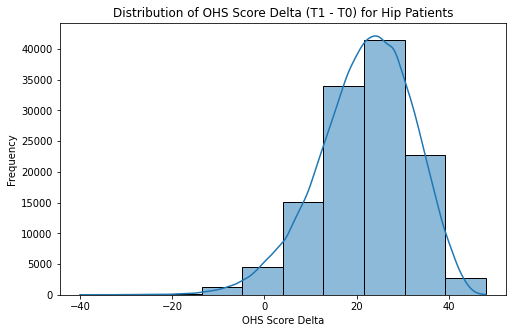

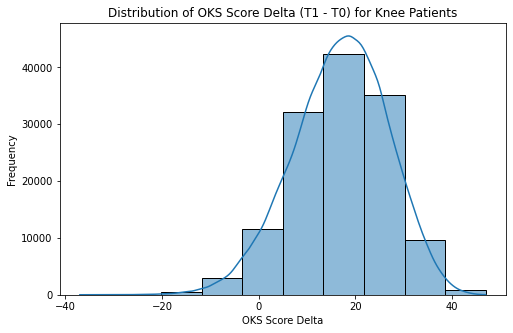

In [14]:
# Generate a graph for df_hip_provider and df_knee_provider showing the delta between t0 and t1 scores only for patients who have both scores filled.
import matplotlib.pyplot as plt
import seaborn as sns

df_hip = globals().get("df_hip_provider")
df_knee = globals().get("df_knee_provider")
if df_hip is not None:
    # Filter for patients with both scores filled
    df_hip_filtered = df_hip.dropna(subset=['ohs_t0_score', 'ohs_t1_score']).copy()
    # Calculate delta
    df_hip_filtered['ohs_delta'] = df_hip_filtered['ohs_t1_score'] - df_hip_filtered['ohs_t0_score']
    
    # Plot delta distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df_hip_filtered['ohs_delta'], bins=10, kde=True)
    plt.title('Distribution of OHS Score Delta (T1 - T0) for Hip Patients')
    plt.xlabel('OHS Score Delta')
    plt.ylabel('Frequency')
    plt.show()
if df_knee is not None:
    # Filter for patients with both scores filled
    df_knee_filtered = df_knee.dropna(subset=['oks_t0_score', 'oks_t1_score']).copy()
    # Calculate delta
    df_knee_filtered['oks_delta'] = df_knee_filtered['oks_t1_score'] - df_knee_filtered['oks_t0_score']
    
    # Plot delta distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df_knee_filtered['oks_delta'], bins=10, kde=True)
    plt.title('Distribution of OKS Score Delta (T1 - T0) for Knee Patients')
    plt.xlabel('OKS Score Delta')
    plt.ylabel('Frequency')
    plt.show()


# Initial EDA and Missing Value Analysis

In [ ]:
# ============================================================================
# DATA CLEANING: CREATE CLEAN DF_KNEE_PROVIDER
# ============================================================================

import pandas as pd
import numpy as np

# Load the original data
df_knee_provider_original = globals().get("df_knee_provider")

if df_knee_provider_original is not None:
    print("="*80)
    print("CREATING CLEAN DF_KNEE_PROVIDER DATASET")
    print("="*80)
    
    # Make a copy to work with
    df_knee_provider = df_knee_provider_original.copy()
    
    print(f"\nOriginal dataset:")
    print(f"  Total records: {len(df_knee_provider):,}")
    print(f"  Total columns: {df_knee_provider.shape[1]}")
    
    # -------------------------------------------------------------------------
    # STEP 1: Remove incomplete OKS scores
    # -------------------------------------------------------------------------
    
    print("\n" + "-"*80)
    print("STEP 1: Removing records with incomplete OKS scores")
    print("-"*80)
    
    # Count before removal
    before_count = len(df_knee_provider)
    
    # Identify incomplete records
    incomplete_oks_mask = df_knee_provider['oks_t0_score'].isna()
    incomplete_count = incomplete_oks_mask.sum()
    
    print(f"  - Missing oks_t0_score only: {df_knee_provider['oks_t0_score'].isna().sum():,}")
    
    # Remove incomplete records
    df_knee_provider = df_knee_provider[~incomplete_oks_mask].copy()
    
    after_step1 = len(df_knee_provider)
    print(f"\n✓ Removed {incomplete_count:,} records")
    print(f"  Remaining: {after_step1:,} records ({after_step1/before_count*100:.2f}% of original)")
    
    # -------------------------------------------------------------------------
    # STEP 2: Remove surgeries with positive revision flag
    # -------------------------------------------------------------------------
    
    print("\n" + "-"*80)
    print("STEP 2: Removing records with positive revision flag")
    print("-"*80)
    
    if 'revision_flag' in df_knee_provider.columns:
        # Count before removal
        before_step2 = len(df_knee_provider)
        
        # Identify revision cases
        revision_mask = (df_knee_provider['revision_flag'] == 1)
        revision_count = revision_mask.sum()
        
        print(f"\nRecords with revision flag = 1: {revision_count:,}")
        
        # Remove revision cases
        df_knee_provider = df_knee_provider[df_knee_provider['revision_flag'] != 1].copy()
        
        after_step2 = len(df_knee_provider)
        print(f"\n✓ Removed {revision_count:,} records")
        print(f"  Remaining: {after_step2:,} records ({after_step2/before_step2*100:.2f}% after step 1)")
    else:
        print("\n⚠ Warning: 'revision' column not found in dataset")
        print("  Skipping revision flag removal")
    
    # -------------------------------------------------------------------------
    # FINAL SUMMARY
    # -------------------------------------------------------------------------
    
    print("\n\n" + "="*80)
    print("FINAL CLEAN DATASET SUMMARY")
    print("="*80)
    
    final_count = len(df_knee_provider)
    total_removed = before_count - final_count
    
    summary_data = [
        {'Metric': 'Original records', 'Value': f"{before_count:,}"},
        {'Metric': 'Records removed (incomplete OKS)', 'Value': f"{incomplete_count:,}"},
        {'Metric': 'Records removed (revision=1)', 'Value': f"{revision_count:,}" if 'revision' in df_knee_provider_original.columns else "N/A"},
        {'Metric': '─' * 30, 'Value': '─' * 15},
        {'Metric': 'Total records removed', 'Value': f"{total_removed:,}"},
        {'Metric': 'FINAL CLEAN RECORDS', 'Value': f"{final_count:,}"},
        {'Metric': 'Retention rate', 'Value': f"{final_count/before_count*100:.2f}%"},
    ]
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + summary_df.to_string(index=False))
    
    # -------------------------------------------------------------------------
    # VERIFY CLEAN DATASET
    # -------------------------------------------------------------------------
    
    print("\n\n" + "="*80)
    print("VERIFICATION OF CLEAN DATASET")
    print("="*80)
    
    # Verify no missing OKS scores
    missing_t0 = df_knee_provider['oks_t0_score'].isna().sum()
    missing_t1 = df_knee_provider['oks_t1_score'].isna().sum()
    
    print(f"\n✓ OKS Score Completeness:")
    print(f"  - Missing oks_t0_score: {missing_t0:,} (should be 0)")
    print(f"  - Missing oks_t1_score: {missing_t1:,} (should be 0)")
    
    # Verify no revision cases
    if 'revision' in df_knee_provider.columns:
        revision_remaining = (df_knee_provider['revision_flag'] == 1).sum()
        print(f"\n✓ Revision Flag:")
        print(f"  - Records with revision=1: {revision_remaining:,} (should be 0)")
    
    # Show data types and shape
    print(f"\n✓ Dataset Shape:")
    print(f"  - Rows: {df_knee_provider.shape[0]:,}")
    print(f"  - Columns: {df_knee_provider.shape[1]}")
    
    # Display first few rows
    print(f"\n✓ First 5 rows of clean dataset:")
    print(df_knee_provider.head())
    
    # -------------------------------------------------------------------------
    # SAVE TO GLOBAL NAMESPACE
    # -------------------------------------------------------------------------
    
    # Update the global variable with clean data
    globals()['df_knee_provider'] = df_knee_provider
    
    print("\n\n" + "="*80)
    print("✓ CLEAN DATASET CREATED SUCCESSFULLY!")
    print("="*80)
    print(f"\nThe variable 'df_knee_provider' now contains {final_count:,} clean records")
    print("\nCleaning criteria applied:")
    print("  1. ✓ Removed all records with missing oks_t0_score")
    print("  2. ✓ Removed all records with revision flag = 1")
    
else:
    print("df_knee_provider not loaded")

CREATING CLEAN DF_KNEE_PROVIDER DATASET

Original dataset:
  Total records: 139,236
  Total columns: 81

--------------------------------------------------------------------------------
STEP 1: Removing records with incomplete OKS scores
--------------------------------------------------------------------------------
  - Missing oks_t0_score only: 1,669

✓ Removed 1,669 records
  Remaining: 137,567 records (98.80% of original)

--------------------------------------------------------------------------------
STEP 2: Removing records with positive revision flag
--------------------------------------------------------------------------------

Records with revision flag = 1: 5,185

✓ Removed 5,185 records
  Remaining: 132,382 records (96.23% after step 1)


FINAL CLEAN DATASET SUMMARY

                          Metric           Value
                Original records         139,236
Records removed (incomplete OKS)           1,669
    Records removed (revision=1)             N/A
  ─────────

In [ ]:
# Save the clean dataset to parquet file
import os

# Define the output path
output_path = "/Users/asaras/OneDrive - KPMG/EIAISI Academy/ames-housing/EAISI-Group-Project---NHS/data/cleaned/knee-provider-cleaned.parquet"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the clean dataset
df_knee_provider.to_parquet(output_path)

print(f"✓ Clean dataset saved to: {output_path}")
print(f"  Records saved: {len(df_knee_provider):,}")

In [ ]:
# ============================================================================
# COMPREHENSIVE MISSING VALUE ANALYSIS AND DATA CLEANING FOR DF_KNEE_PROVIDER
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df_knee_provider = pd.read_parquet("/Users/asaras/OneDrive - KPMG/EIAISI Academy/ames-housing/EAISI-Group-Project---NHS/data/cleaned/knee-provider-cleaned.parquet")

if df_knee_provider is not None:
    print("="*80)
    print("COMPREHENSIVE MISSING VALUE ANALYSIS FOR DF_KNEE_PROVIDER")
    print("="*80)
    print(f"\nInitial dataset shape: {df_knee_provider.shape}")
    print(f"Total records: {len(df_knee_provider):,}\n")
    
    # -------------------------------------------------------------------------
    # 1. COMPREHENSIVE MISSING VALUE ANALYSIS
    # -------------------------------------------------------------------------
    
    print("\n" + "="*80)
    print("SECTION 1: MISSING VALUE ANALYSIS BY CATEGORY")
    print("="*80)
    
    # Define variable categories
    outcome_vars = ['oks_t0_score', 'oks_t1_score']
    
    oks_individual_t0 = [col for col in df_knee_provider.columns if col.startswith('oks_t0_') and col != 'oks_t0_score']
    oks_individual_t1 = [col for col in df_knee_provider.columns if col.startswith('oks_t1_') and col != 'oks_t1_score']
    
    demographic_vars = ['age_band', 'gender']
    
    health_conditions = ['heart_disease',
                        'high_bp',
                        'stroke',
                        'circulation',
                        'lung_disease',
                        'diabetes',
                        'kidney_disease',
                        'nervous_system',
                        'liver_disease',
                        'cancer',
                        'depression',
                        'arthritis',
                        't0_assisted',
                        't0_assisted_by',
                        't0_symptom_period',
                        't0_previous_surgery',
                        't0_living_arrangements',
                        't0_disability',
                        't0_mobility',
                        't0_self_care',
                        't0_activity',
                        't0_discomfort',
                        't0_anxiety',]
    
    revision_flag = ['revision_flag']
    
    # Function to create missing value summary
    
    def create_missing_summary(df, columns, category_name):
        if not columns:
            return None
        
        columns = [col for col in columns if col in df.columns]
        if not columns:
            return None
        
        print(f"\n{'-'*80}")
        print(f"{category_name}")
        print(f"{'-'*80}")
        
        missing_data = []
        for col in columns:
            total = len(df)
            
            # Count NaN values
            missing_null = df[col].isnull().sum()
            
            # Count values equal to 9 (numeric or string)
            missing_nine = (df[col].astype(str) == "9").sum()
            
            # Total missing = NaN + "9"
            missing_total = missing_null + missing_nine
            present = total - missing_total
            
            missing_pct = (missing_total / total) * 100
            
            missing_data.append({
                'Variable': col,
                'Present': f"{present:,}",
                'Missing (NaN)': f"{missing_null:,}",
                'Missing (Value=9)': f"{missing_nine:,}",
                'Total Missing': f"{missing_total:,}",
                'Missing %': f"{missing_pct:.2f}%"
            })
        
        missing_df = pd.DataFrame(missing_data)
        print(missing_df.to_string(index=False))
        return missing_df

    
    # Create summaries for each category
    outcome_summary = create_missing_summary(df_knee_provider, outcome_vars, "PRIMARY OUTCOME VARIABLES")
    oks_t0_summary = create_missing_summary(df_knee_provider, oks_individual_t0, "OKS T0 INDIVIDUAL ITEMS")
    #oks_t1_summary = create_missing_summary(df_knee_provider, oks_individual_t1, "OKS T1 INDIVIDUAL ITEMS")
    demographic_summary = create_missing_summary(df_knee_provider, demographic_vars, "DEMOGRAPHIC VARIABLES")
    health_summary = create_missing_summary(df_knee_provider, health_conditions, "HEALTH CONDITIONS")
    #revision_summary = create_missing_summary(df_knee_provider, revision_flag, "REVISION FLAG")
    
    # -------------------------------------------------------------------------
    # 2. VISUALIZATION OF MISSING PATTERNS
    # -------------------------------------------------------------------------

    print("\n\n" + "="*80)
    print("SECTION 4: MISSING VALUE VISUALIZATIONS")
    print("="*80)

    # Combine all summaries into one DataFrame for visualization
    all_summaries = [outcome_summary, oks_t0_summary, demographic_summary, health_summary, revision_summary]
    missing_viz_df = pd.concat([df for df in all_summaries if df is not None], ignore_index=True)

    # Convert numeric columns back from strings for plotting
    missing_viz_df['Total Missing'] = missing_viz_df['Total Missing'].str.replace(',', '').astype(int)
    missing_viz_df['Missing %'] = missing_viz_df['Missing %'].str.replace('%', '').astype(float)

    # Exclude health condition variables (because 9 = valid "no condition")
    exclude_vars = [
        'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease',
        'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease',
        'cancer', 'depression', 'arthritis'
    ]
    missing_viz_df = missing_viz_df[~missing_viz_df['Variable'].isin(exclude_vars)]

    # Sort by missing percentage
    missing_viz_df = missing_viz_df.sort_values(by='Missing %', ascending=False)

    # --- Bar chart: Missing counts and percentages ---
    plt.figure(figsize=(14, 8))
    sns.barplot(data=missing_viz_df, y='Variable', x='Total Missing', palette='Blues_r')
    plt.title('Missing Values Count by Variable (Excluding Health Conditions)')
    plt.xlabel('Number of Missing Values')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 8))
    sns.barplot(data=missing_viz_df, y='Variable', x='Missing %', palette='Reds_r')
    plt.title('Missing Values Percentage by Variable (Excluding Health Conditions)')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()

    # --- Optional: Distribution plots for variables with missing values ---
    for var in missing_viz_df['Variable']:
        if missing_viz_df.loc[missing_viz_df['Variable'] == var, 'Total Missing'].values[0] > 0:
            plt.figure(figsize=(8, 4))
            sns.histplot(df_knee_provider[var], kde=False, bins=20)
            plt.title(f'Distribution of {var} (with missing values)')
            plt.xlabel(var)
            plt.ylabel('Frequency')
            plt.tight_layout()
            plt.show()

    print("\nVisualizations generated: Missing counts, percentages, heatmap, and distributions (excluding health condition variables).")

else:
    print("df_knee_provider not loaded")